In [24]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = 7
hidden_size = 16
output_size = 7

learning_rate = 0.01
epochs = 200

## Reber Grammar Graph

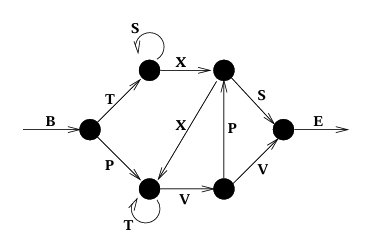

In [26]:
adj_matrix = [
#    0    1    2    3    4    5    6    7
    [0,  'B', 0,   0,   0,   0,   0,   0],   # 0 Start
    [0,   0, 'T', 'P',  0,   0,   0,   0],   # 1
    [0,   0, 'S',  0,  'X',  0,   0,   0],   # 2
    [0,   0,  0,  'T',  0,  'V',  0,   0],   # 3
    [0,   0,  0,  'X',  0,   0,  'S',  0],   # 4
    [0,   0,  0,   0,  'P',  0,  'V',  0],   # 5
    [0,   0,  0,   0,   0,   0,   0,  'E'],  # 6
    [0,   0,  0,   0,   0,   0,   0,   0]    # 7 End
]

## Dataset Generation

In [27]:
import random

Targets depend on the current letter:

outer B       → ['T', 'P']  
outer T/P     → ['B']       
inner Reber   → depends on graph state, not only letter
inner E       → [outer]     
outer T/P     → ['E']       
final E       → ['B']

In [28]:
def datasetify(num):
  dataset=[]

  for _ in range(num):
    i=1
    seq='B'

    while i!=7:
      path=[]
      for j in range(0,8):
        if adj_matrix[i][j]!=0:
          path.append(j)

      choosen=random.choice(path)
      seq+=adj_matrix[i][choosen]

      i=choosen
    dataset.append(seq)

  out={
     1:['T','P'],
     2:['S','X'],
     3:['T','V'],
     4:['X','S'],
     5:['P','V'],
     6:['E']
     } # only for inner seq

  embedded_dataset=[]
  inputs=[]
  targets=[]
  for seq in dataset:

    outer=random.choice(['T','P'])
    embedded_seq='B'+outer+seq+outer+'E'
    embedded_dataset.append(embedded_seq)

    # Outer B -> T/P
    inputs.append('B')
    targets.append(['T', 'P'])

    # Outer T/P -> inner Reber starts with B
    inputs.append(outer)
    targets.append(['B'])

    # Inner Reber part
    state = 0

    for letter in seq:
      inputs.append(letter)

      #state update
      for j in range(8):
          if adj_matrix[state][j] == letter:
              state = j
              break
      if state == 7:
        targets.append([outer])
      else:
        targets.append(out[state])

    # Final outer T/P -> E
    inputs.append(outer)
    targets.append(['E'])

    # Final outer E -> B
    inputs.append('E')
    targets.append(['B'])

  cerg=''
  seq_start=[]
  for seq in embedded_dataset:
    seq_start.append(len(cerg))
    cerg+=seq

  return embedded_dataset, inputs, targets, seq_start, cerg

In [29]:
train_embedded, train_inputs, train_targets, train_seq_start, train_cerg = datasetify(1000)

test_embedded, test_inputs, test_targets, test_seq_start, test_cerg = datasetify(200)

## Encoding

In [30]:
def encoding(inputs,targets):
  symbols = {'B':0, 'T':1, 'P':2, 'S':3, 'X':4, 'V':5, 'E':6}
  encoded_inputs=[]
  encoded_outputs=[]

  for i in inputs:
    vector=[0,0,0,0,0,0,0]
    vector[symbols[i]]=1
    encoded_inputs.append(vector)

  for i in targets:
    vector=[0,0,0,0,0,0,0]
    for j in i:
      vector[symbols[j]]=1
    encoded_outputs.append(vector)

  return encoded_inputs, encoded_outputs

In [31]:
train_inputs_encoded, train_targets_encoded = encoding(train_inputs, train_targets)
test_inputs_encoded, test_targets_encoded = encoding(test_inputs, test_targets)

In [32]:
print(len(train_inputs_encoded), len(train_targets_encoded))
print(len(test_inputs_encoded), len(test_targets_encoded))

print(train_inputs[:5])
print(train_targets[:5])

print(train_inputs_encoded[:5])
print(train_targets_encoded[:5])

12142 12142
2414 2414
['B', 'T', 'B', 'T', 'X']
[['T', 'P'], ['B'], ['T', 'P'], ['S', 'X'], ['X', 'S']]
[[1, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [0, 1, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0]]
[[0, 1, 1, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0], [0, 1, 1, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0], [0, 0, 0, 1, 1, 0, 0]]


## converting to pytorch tensors

In [33]:
train_inputs_encoded_tensors=torch.tensor(train_inputs_encoded,dtype=torch.float32)
train_targets_encoded_tensors=torch.tensor(train_targets_encoded,dtype=torch.float32)

test_inputs_encoded_tensors=torch.tensor(test_inputs_encoded,dtype=torch.float32)
test_targets_encoded_tensors=torch.tensor(test_targets_encoded,dtype=torch.float32)

In [34]:
train_inputs_encoded_tensors = train_inputs_encoded_tensors.to(device)
train_targets_encoded_tensors = train_targets_encoded_tensors.to(device)

test_inputs_encoded_tensors = test_inputs_encoded_tensors.to(device)
test_targets_encoded_tensors = test_targets_encoded_tensors.to(device)

In [35]:
print(train_inputs_encoded_tensors.shape)
print(train_targets_encoded_tensors.shape)

print(test_inputs_encoded_tensors.shape)
print(test_targets_encoded_tensors.shape)

torch.Size([12142, 7])
torch.Size([12142, 7])
torch.Size([2414, 7])
torch.Size([2414, 7])


## GRU Architecture

In [36]:
class GRUBlock(nn.Module):
  def __init__(self,input_size, hidden_size):
    super().__init__()
    self.input_gate1 = nn.Linear(input_size + hidden_size, hidden_size, dtype=torch.float32) # sigmoid 1
    self.input_gate2 = nn.Linear(input_size + hidden_size, hidden_size, dtype=torch.float32) # sigmoid 2
    self.input_gate3 = nn.Linear(input_size + hidden_size, hidden_size, dtype=torch.float32) # tanh

  def forward(self,x_t,h_t_1):
    r_t=torch.sigmoid(self.input_gate1(torch.cat((x_t,h_t_1),dim=1))) # reset gate
    z_t=torch.sigmoid(self.input_gate2(torch.cat((x_t,h_t_1),dim=1))) # update gate
    h_t_bar=torch.tanh(self.input_gate3(torch.cat(((h_t_1*r_t),x_t),dim=1))) # candidate hidden state
    h_t=((1-z_t)*h_t_1) + (z_t*h_t_bar) # final hidden
    return h_t,r_t,z_t

In [37]:
# wrapper function
class GRU(nn.Module):
  def __init__(self,input_size,hidden_size,output_size):
    super().__init__()
    self.hidden_size=hidden_size
    self.grublock=GRUBlock(input_size,hidden_size)
    self.fc=nn.Linear(hidden_size,output_size)

  def forward(self,x): # x shape: [batch_size, seq_len, input_size]

    hidden_states=[]
    reset_gates = []
    update_gates = []

    batch_size=x.shape[0]
    h_t=torch.zeros(batch_size,self.hidden_size,device=x.device)
    for i in range(x.shape[1]):
      x_t=x[:,i,:]
      h_t,r_t,z_t=self.grublock(x_t,h_t)

      hidden_states.append(h_t)
      reset_gates.append(r_t)
      update_gates.append(z_t)

    hidden_states=torch.stack(hidden_states, dim=1)
    reset_gates=torch.stack(reset_gates, dim=1)
    update_gates=torch.stack(update_gates, dim=1)

    logits=self.fc(hidden_states)

    return logits,reset_gates,update_gates,hidden_states

In [38]:
# create model
model=GRU(input_size,hidden_size,output_size)
model=model.to(device)

#loss func
criterion = nn.BCEWithLogitsLoss()

#define optimizer
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [39]:
train_x=train_inputs_encoded_tensors.unsqueeze(0)
train_y=train_targets_encoded_tensors.unsqueeze(0)

test_x=test_inputs_encoded_tensors.unsqueeze(0)
test_y=test_targets_encoded_tensors.unsqueeze(0)

In [40]:
#training loop
train_loss_history = []
final_epoch_loss = []
for epoch in range(epochs):
    model.train()

    #forward pass
    predictions,reset_gates,update_gates,hidden_states=model(train_x)

    #loss
    loss=criterion(predictions,train_y)

    #zero gradient
    optimizer.zero_grad()

    #backward pass
    loss.backward()

    #update params
    optimizer.step()

    #print loss
    avg_loss = loss.item()
    train_loss_history.append(avg_loss)

    if epoch == epochs - 1:
        final_epoch_loss.append(avg_loss)

    print(f"Epoch: {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch: 1/200, Loss: 0.6962
Epoch: 2/200, Loss: 0.6805
Epoch: 3/200, Loss: 0.6634
Epoch: 4/200, Loss: 0.6441
Epoch: 5/200, Loss: 0.6217
Epoch: 6/200, Loss: 0.5961
Epoch: 7/200, Loss: 0.5690
Epoch: 8/200, Loss: 0.5452
Epoch: 9/200, Loss: 0.5312
Epoch: 10/200, Loss: 0.5274
Epoch: 11/200, Loss: 0.5284
Epoch: 12/200, Loss: 0.5300
Epoch: 13/200, Loss: 0.5309
Epoch: 14/200, Loss: 0.5312
Epoch: 15/200, Loss: 0.5308
Epoch: 16/200, Loss: 0.5299
Epoch: 17/200, Loss: 0.5285
Epoch: 18/200, Loss: 0.5267
Epoch: 19/200, Loss: 0.5249
Epoch: 20/200, Loss: 0.5231
Epoch: 21/200, Loss: 0.5215
Epoch: 22/200, Loss: 0.5201
Epoch: 23/200, Loss: 0.5189
Epoch: 24/200, Loss: 0.5178
Epoch: 25/200, Loss: 0.5169
Epoch: 26/200, Loss: 0.5161
Epoch: 27/200, Loss: 0.5154
Epoch: 28/200, Loss: 0.5147
Epoch: 29/200, Loss: 0.5139
Epoch: 30/200, Loss: 0.5131
Epoch: 31/200, Loss: 0.5122
Epoch: 32/200, Loss: 0.5111
Epoch: 33/200, Loss: 0.5101
Epoch: 34/200, Loss: 0.5089
Epoch: 35/200, Loss: 0.5077
Epoch: 36/200, Loss: 0.5064
E

In [41]:
import matplotlib.pyplot as plt

In [42]:
model.eval()

with torch.no_grad():
    test_predictions, test_reset_gates, test_update_gates, test_hidden_states = model(test_x)

test_loss = criterion(test_predictions, test_y)
print(f"Test Loss: {test_loss.item():.4f}")

test_probs = torch.sigmoid(test_predictions)
test_pred_binary = (test_probs >= 0.5).float()

exact_matches = (test_pred_binary == test_y).all(dim=2)
exact_match_accuracy = exact_matches.float().mean().item()

print(f"Exact Match Accuracy: {exact_match_accuracy * 100:.2f}%")

Test Loss: 0.0327
Exact Match Accuracy: 95.98%


In [43]:
idx_to_symbol = {0:'B', 1:'T', 2:'P', 3:'S', 4:'X', 5:'V', 6:'E'}

def decode_multihot(vector):
    symbols = []
    for idx, value in enumerate(vector):
        if value == 1:
            symbols.append(idx_to_symbol[idx])
    return symbols

for i in range(20):
    input_symbol = test_inputs[i]
    actual_target = decode_multihot(test_y[0, i].cpu())
    predicted_target = decode_multihot(test_pred_binary[0, i].cpu())

    print(f"Input: {input_symbol} | Actual: {actual_target} | Predicted: {predicted_target}")

Input: B | Actual: ['T', 'P'] | Predicted: ['T', 'P']
Input: T | Actual: ['B'] | Predicted: ['S', 'X']
Input: B | Actual: ['T', 'P'] | Predicted: ['T', 'P']
Input: P | Actual: ['T', 'V'] | Predicted: ['T', 'V']
Input: V | Actual: ['P', 'V'] | Predicted: ['P', 'V']
Input: V | Actual: ['E'] | Predicted: ['E']
Input: E | Actual: ['T'] | Predicted: ['T', 'P']
Input: T | Actual: ['E'] | Predicted: ['E']
Input: E | Actual: ['B'] | Predicted: ['B']
Input: B | Actual: ['T', 'P'] | Predicted: ['T', 'P']
Input: T | Actual: ['B'] | Predicted: ['B']
Input: B | Actual: ['T', 'P'] | Predicted: ['T', 'P']
Input: P | Actual: ['T', 'V'] | Predicted: ['T', 'V']
Input: V | Actual: ['P', 'V'] | Predicted: ['P', 'V']
Input: V | Actual: ['E'] | Predicted: ['E']
Input: E | Actual: ['T'] | Predicted: ['P']
Input: T | Actual: ['E'] | Predicted: ['E']
Input: E | Actual: ['B'] | Predicted: ['B']
Input: B | Actual: ['T', 'P'] | Predicted: ['T', 'P']
Input: T | Actual: ['B'] | Predicted: ['B']


## Plottings

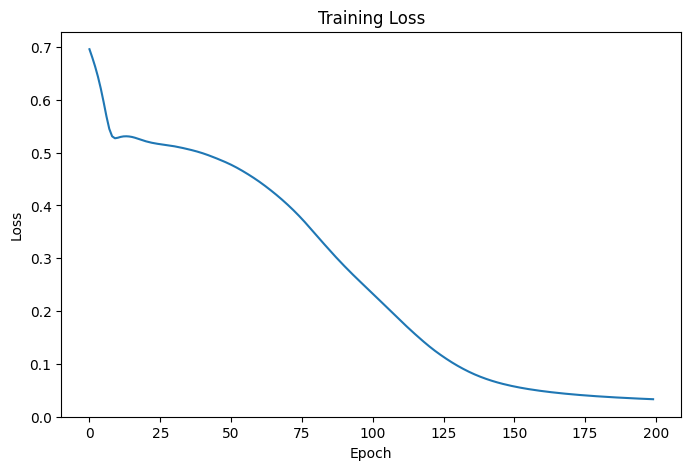

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

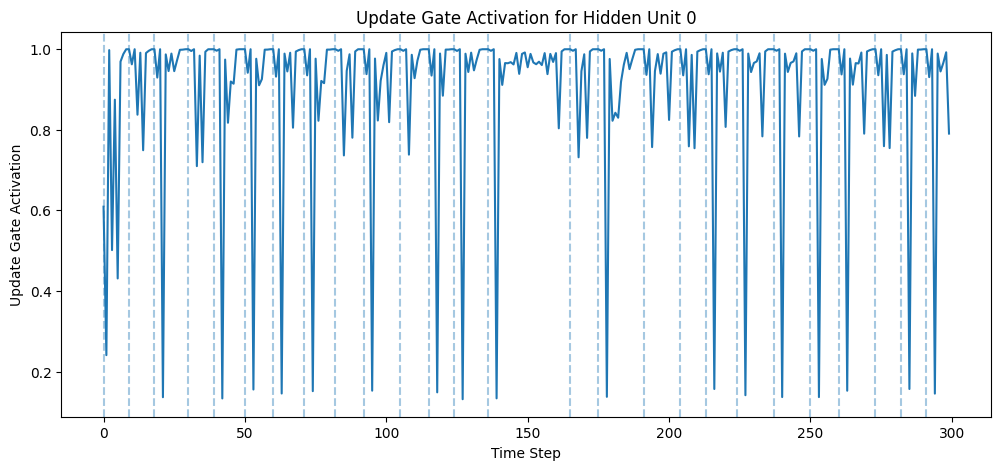

In [45]:
neuron_idx = 0
max_points = 300

update_values = test_update_gates[0, :max_points, neuron_idx].detach().cpu().numpy()

plt.figure(figsize=(12, 5))
plt.plot(update_values)

for start in test_seq_start:
    if start < max_points:
        plt.axvline(start, linestyle="--", alpha=0.4)

plt.xlabel("Time Step")
plt.ylabel("Update Gate Activation")
plt.title(f"Update Gate Activation for Hidden Unit {neuron_idx}")
plt.show()

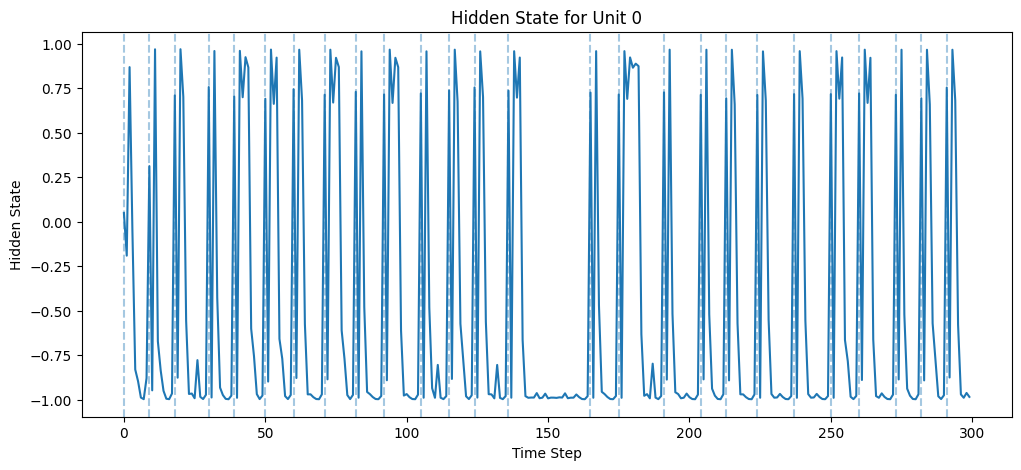

In [46]:
hidden_values = test_hidden_states[0, :max_points, neuron_idx].detach().cpu().numpy()

plt.figure(figsize=(12, 5))
plt.plot(hidden_values)

for start in test_seq_start:
    if start < max_points:
        plt.axvline(start, linestyle="--", alpha=0.4)

plt.xlabel("Time Step")
plt.ylabel("Hidden State")
plt.title(f"Hidden State for Unit {neuron_idx}")
plt.show()